<a href="https://colab.research.google.com/github/Shawnpeter578/practise_ML/blob/main/simpleLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('/content/height-weight (1).csv')

In [3]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


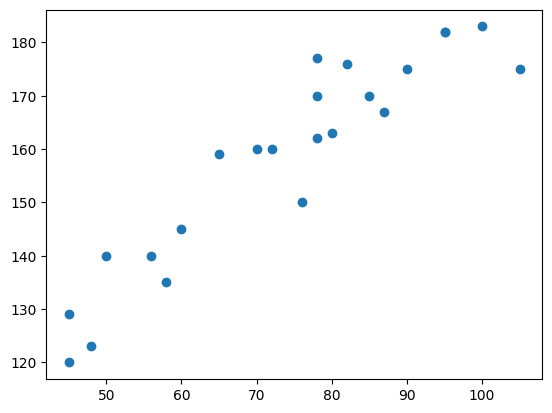

In [4]:
## scatter plot

plt.scatter(df['Weight'],df['Height'] )

In [5]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [6]:
import seaborn as sns

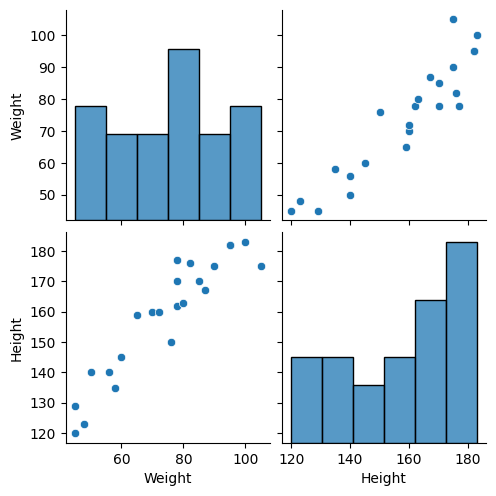

In [7]:
sns.pairplot(df)

In [8]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [12]:
X=df[['Weight']]

In [13]:
type(X)

pandas.core.frame.DataFrame

In [14]:
X.shape

(23, 1)

In [15]:
y = df['Height']

In [16]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [17]:
np.array(y).shape

(23,)

In [18]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [21]:
X_train.shape

(17, 1)

## STANDARDIZATION

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [25]:
X_train = scaler.fit_transform(X_train)

In [26]:
X_test = scaler.transform(X_test)

In [28]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

## Apply Simple Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression

In [31]:
regression = LinearRegression(n_jobs=-1)

In [32]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [35]:
regression.coef_  ## 1 unit movement w.r.t y axis it leads to 17.29...

array([17.2982057])

In [36]:
regression.intercept_  ## this gives the intercept

np.float64(156.47058823529412)

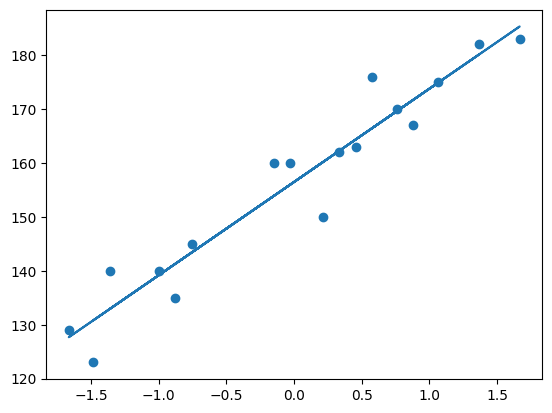

In [38]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

## prediction

In [40]:
y_pred = regression.predict(X_test)

In [41]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [42]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [43]:
mse

114.84069295228699

In [44]:
score = r2_score(y_test,y_pred)

In [45]:
score

0.7360826717981276

#adjusted r squre

In [46]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

## OLS LINEAR REGRESSION

In [47]:
import statsmodels.api as sm

In [48]:
model = sm.OLS(y_train,X_train).fit()

In [50]:
prediction = model.predict(X_test)

In [51]:
prediction

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [52]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 19 Jul 2026   Prob (F-statistic):                       0.664
Time:                        19:17:30   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## prediction for new data

In [56]:
regression.predict(scaler.transform([[72]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])